In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df=pd.read_csv('/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:

df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace = True)

In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True,dtype=int)

In [12]:
X=df.drop(columns=["Exited"])
y=df["Exited"]

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [14]:
X_train.shape

(8000, 11)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [16]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [17]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [18]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential

2026-02-04 14:15:09.195345: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770214509.646532      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770214509.794090      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770214510.982197      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770214510.982244      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770214510.982247      24 computation_placer.cc:177] computation placer alr

In [19]:


model = Sequential([
    Input(shape=(11,)), 
    Dense(11, activation='relu'),
    Dense(11,activation='relu'),
    Dense(1, activation='sigmoid')
])

I0000 00:00:1770214528.902160      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770214528.907973      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [22]:
history=model.fit(X_train_scaled,y_train,epochs=50,validation_split=0.2)

Epoch 1/50


I0000 00:00:1770214531.857225      68 service.cc:152] XLA service 0x7bc2f0002840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770214531.857258      68 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770214531.857263      68 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770214532.248662      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


 81/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7638 - loss: 0.5775

I0000 00:00:1770214533.149585      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7815 - loss: 0.5486 - val_accuracy: 0.7969 - val_loss: 0.4705
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7897 - loss: 0.4768 - val_accuracy: 0.8125 - val_loss: 0.4359
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8122 - loss: 0.4319 - val_accuracy: 0.8150 - val_loss: 0.4229
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8173 - loss: 0.4235 - val_accuracy: 0.8169 - val_loss: 0.4165
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8253 - loss: 0.4069 - val_accuracy: 0.8200 - val_loss: 0.4117
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8315 - loss: 0.4038 - val_accuracy: 0.8263 - val_loss: 0.4049
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8270 - loss: 0.4001 - val_accuracy: 0.8294 - val_loss: 0.3966
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8384 - loss: 0.3862 - val_accuracy: 0.8381 - val_

In [23]:
model.layers[0].get_weights()

[array([[-0.05194285,  0.06048405,  0.1929663 ,  0.07296176, -0.1028047 ,
          0.15291452,  0.07565524,  0.10278805,  0.0706336 ,  0.41572416,
         -0.3142929 ],
        [ 0.7306591 , -0.72536737,  0.20541973, -0.696857  , -0.8280696 ,
          0.8886333 ,  0.09840575,  0.05769472, -0.20568533, -0.6764864 ,
          0.22934027],
        [ 0.11651879, -0.03951769,  0.14434263, -0.09168294, -0.16970418,
         -0.14561777,  0.39921513,  0.10990757,  0.09523001, -0.19113979,
         -0.5158502 ],
        [-0.37916872,  0.11011223, -0.82661223, -0.8531539 , -0.18572116,
          0.2568235 , -0.21682616, -0.12241036,  0.19499373,  0.1630902 ,
         -0.29484123],
        [ 0.4644717 ,  0.12125194, -0.7061937 ,  0.46508455,  0.08387187,
          0.6708462 ,  0.44435552, -0.58594114,  1.3846421 , -0.00834207,
         -0.15278628],
        [-0.01788486, -0.02336154, -0.02830707, -0.03299684, -0.07196427,
          0.09251457,  0.31985193,  0.25640568, -0.02745718, -0.0689263

In [24]:
model.layers[1].get_weights()

[array([[-0.6232906 , -0.13008246,  0.48906347, -0.00996917, -0.78426737,
          0.25194213,  0.15516146,  0.43776414, -0.32337728, -0.30075875,
          0.58679557],
        [ 0.40483144, -0.73808163,  0.5396288 , -0.3203148 , -0.7249204 ,
          0.3533732 ,  0.641713  , -0.29483598,  0.72444683,  0.48902708,
          0.00436728],
        [-0.40918133, -0.6696836 , -0.13821794, -0.32023457,  0.43774778,
          0.10183888, -0.35654524, -0.28423604, -0.41282538, -0.21590212,
         -0.07859774],
        [ 0.24144231,  0.31633827, -0.02217835,  0.7347827 , -1.0467851 ,
          0.18290676,  0.45103338, -0.2650168 , -0.88977367, -0.76819605,
          0.68549347],
        [-0.18421711,  0.07139403,  0.25695375,  0.43668348, -0.73157626,
          0.52798486,  0.11217894,  0.50299084, -0.02144417,  0.00223296,
         -0.08248474],
        [-0.3754958 ,  0.47020474,  0.25191098, -0.7936669 ,  0.29218385,
         -0.8330651 ,  0.0088093 , -0.03880973,  0.17463566, -0.8083818

In [25]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [26]:
y_pred=np.where(y_log>0.5,1,0)

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8635

In [28]:
import matplotlib.pyplot as plt 

In [29]:
history.history

{'accuracy': [0.7925000190734863,
  0.8020312786102295,
  0.8135937452316284,
  0.8199999928474426,
  0.8246874809265137,
  0.8278124928474426,
  0.8331249952316284,
  0.8403124809265137,
  0.8459374904632568,
  0.848437488079071,
  0.8557812571525574,
  0.8596875071525574,
  0.8589062690734863,
  0.8618749976158142,
  0.862500011920929,
  0.8617187738418579,
  0.8628125190734863,
  0.8651562333106995,
  0.8642187714576721,
  0.8656250238418579,
  0.8660937547683716,
  0.8653125166893005,
  0.8643749952316284,
  0.8654687404632568,
  0.8670312762260437,
  0.8667187690734863,
  0.866406261920929,
  0.8662499785423279,
  0.8670312762260437,
  0.8675000071525574,
  0.866406261920929,
  0.8668749928474426,
  0.866406261920929,
  0.8670312762260437,
  0.8678125143051147,
  0.8667187690734863,
  0.8667187690734863,
  0.867968738079071,
  0.8682812452316284,
  0.8687499761581421,
  0.8696874976158142,
  0.8671875,
  0.8681250214576721,
  0.8692187666893005,
  0.8695312738418579,
  0.867812514

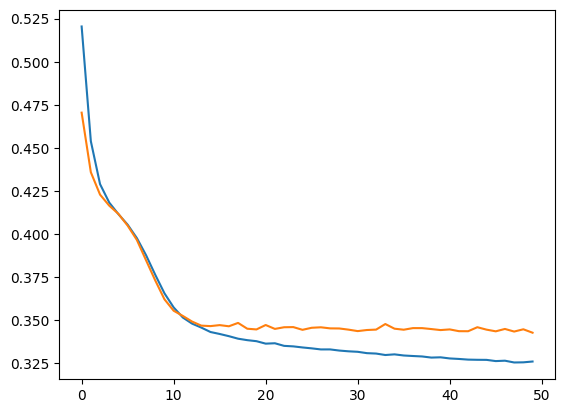

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

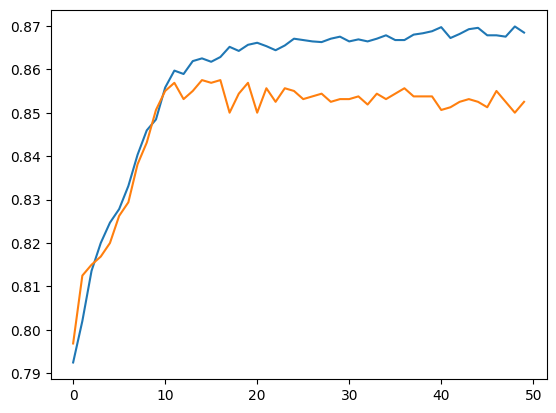

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])